In [23]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SequentialFeatureSelector
from scipy.optimize import linprog
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
df=pd.read_csv("/content/drive/MyDrive/complaints22.csv")
df.head()

,CUSTOMER_TYPE,CUSTOMER_GROUP,PRODUCT,Account Age,Monthly Usage(GBs),Cumulative Usage(GBs),Max Usage(GBs),Customer Satisfication Score
0,CBU,FTTH Home,Internet,25,96,199996,100,97.998011
1,CBU,FTTH Home,Internet,25,96,199975,100,97.997951
2,CBU,Wanadoo-ADSL-Res,Internet,25,96,199974,100,97.995182
3,CBU,FTTH Home,Internet,25,96,199953,100,97.994694
4,CBU,FTTH Home,Internet,25,96,199947,100,97.992793


# **EDA**

In [25]:
df.shape

(10415, 8)

In [26]:
df.isnull().sum()

CUSTOMER_TYPE                   0
CUSTOMER_GROUP                  0
PRODUCT                         0
Account Age                     0
Monthly Usage(GBs)              0
Cumulative Usage(GBs)           0
Max Usage(GBs)                  0
Customer Satisfication Score    0
dtype: int64

In [27]:
df.duplicated().sum()

0

In [28]:
df['Account Age'].unique()

array([25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,
        8,  7,  6,  5,  4,  3,  2,  1])

In [29]:
print('Max: ',df['Monthly Usage(GBs)'].max())
print('Min: ',df['Monthly Usage(GBs)'].min())

Max:  96
Min:  45


In [30]:
print('Max: ',df['Max Usage(GBs)'].max())
print('Min: ',df['Max Usage(GBs)'].min())

Max:  100
Min:  50


In [31]:

df.corr()

<ipython-input-31-2f6f6606aa2c>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Account Age,Monthly Usage(GBs),Cumulative Usage(GBs),Max Usage(GBs),Customer Satisfication Score
Account Age,1.000000,0.998957,0.999097,0.998830,0.992449
Monthly Usage(GBs),0.998957,1.000000,0.999606,0.999546,0.992513
Cumulative Usage(GBs),0.999097,0.999606,1.000000,0.999689,0.993795
Max Usage(GBs),0.998830,0.999546,0.999689,1.000000,0.993442
Customer Satisfication Score,0.992449,0.992513,0.993795,0.993442,1.000000


In [32]:
le=LabelEncoder()

In [33]:
df[['CUSTOMER_TYPE','PRODUCT']]=df[['CUSTOMER_TYPE','PRODUCT']].apply(le.fit_transform)

In [34]:
df.corr()

<ipython-input-34-2f6f6606aa2c>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,CUSTOMER_TYPE,PRODUCT,Account Age,Monthly Usage(GBs),Cumulative Usage(GBs),Max Usage(GBs),Customer Satisfication Score
CUSTOMER_TYPE,1.000000,0.051394,0.016772,0.017328,0.017088,0.017153,0.016557
PRODUCT,0.051394,1.000000,-0.017068,-0.016972,-0.016871,-0.016812,-0.018165
Account Age,0.016772,-0.017068,1.000000,0.998957,0.999097,0.998830,0.992449
Monthly Usage(GBs),0.017328,-0.016972,0.998957,1.000000,0.999606,0.999546,0.992513
Cumulative Usage(GBs),0.017088,-0.016871,0.999097,0.999606,1.000000,0.999689,0.993795
Max Usage(GBs),0.017153,-0.016812,0.998830,0.999546,0.999689,1.000000,0.993442
Customer Satisfication Score,0.016557,-0.018165,0.992449,0.992513,0.993795,0.993442,1.000000


In [35]:
X=df.drop(['Customer Satisfication Score','CUSTOMER_GROUP'], axis=1)
y=df['Customer Satisfication Score']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# **Select From Model Method**

# Linear Regression


Metrics for Linear Regression with SelectFromModel:
Selected Features: Index(['Monthly Usage(GBs)', 'Max Usage(GBs)'], dtype='object')
MAE: 0.58
MSE: 1.872
RMSE: 1.368
R²: 0.982


<ipython-input-37-6ec35419540e>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(result_LR.keys()), y=list(result_LR.values()), palette="viridis")


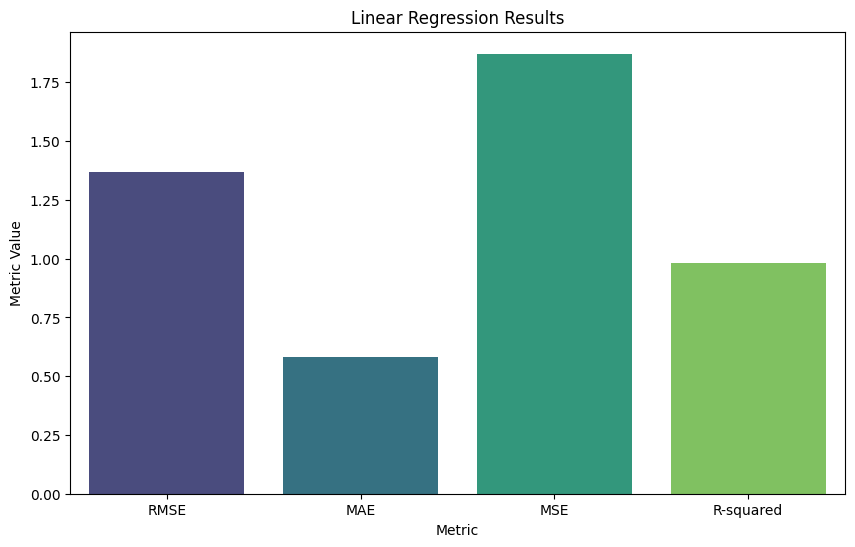

In [37]:
model = LinearRegression()
# Feature selection using SelectFromModel
sfm = SelectFromModel(model)
X_train_selected = sfm.fit_transform(X_train, y_train)
X_test_selected = sfm.transform(X_test)

# Model fitting
model.fit(X_train_selected, y_train)

# Predictions
y_pred = model.predict(X_test_selected)

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"\nMetrics for Linear Regression with SelectFromModel:")
print("Selected Features:", X.columns[sfm.get_support()])
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))
# Store results
result_LR = {'RMSE': rmse, 'MAE': mae, 'MSE': mse, 'R-squared': r2}

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(result_LR.keys()), y=list(result_LR.values()), palette="viridis")
plt.title('Linear Regression Results')
plt.xlabel('Metric')
plt.ylabel('Metric Value')
plt.show()

# Random Forest Regressor


Metrics for Random Forest Regressor with SelectFromModel:
Selected Features: Index(['Cumulative Usage(GBs)'], dtype='object')
MAE: 0.047
MSE: 1.294
RMSE: 1.138
R²: 0.987


<ipython-input-38-4ba436c14e4f>:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(result_RFR.keys()), y=list(result_RFR.values()), palette="viridis")


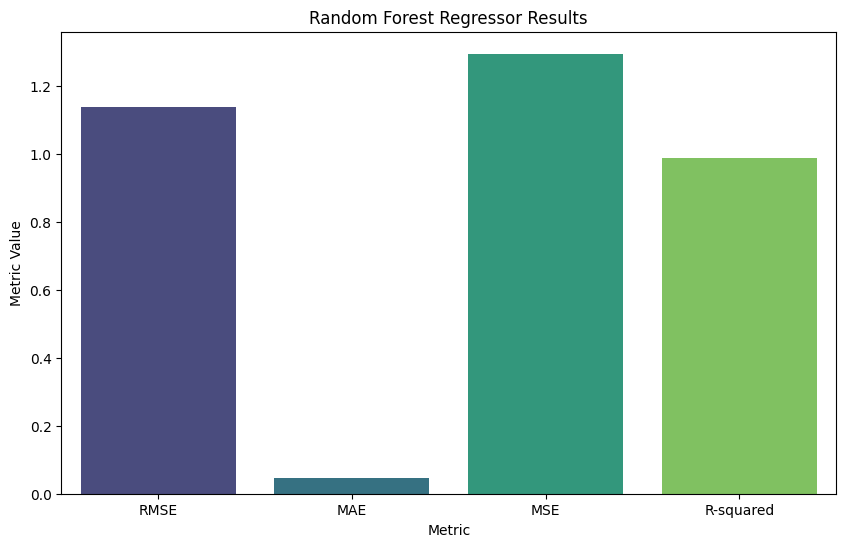

In [38]:
model = RandomForestRegressor()
# Feature selection using SelectFromModel
sfm = SelectFromModel(model)
X_train_selected = sfm.fit_transform(X_train, y_train)
X_test_selected = sfm.transform(X_test)

# Model fitting
model.fit(X_train_selected, y_train)

# Predictions
y_pred = model.predict(X_test_selected)

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"\nMetrics for Random Forest Regressor with SelectFromModel:")
print("Selected Features:", X.columns[sfm.get_support()])
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))
# Store results
result_RFR = {'RMSE': rmse, 'MAE': mae, 'MSE': mse, 'R-squared': r2}

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(result_RFR.keys()), y=list(result_RFR.values()), palette="viridis")
plt.title('Random Forest Regressor Results')
plt.xlabel('Metric')
plt.ylabel('Metric Value')
plt.show()

# SVR

Ignoring the model due to error: when `importance_getter=='auto'`, the underlying estimator SVR should have `coef_` or `feature_importances_` attribute. Either pass a fitted estimator to feature selector or call fit before calling transform.

Metrics for SVR with SelectFromModel:
MAE: 0.251
MSE: 1.415
RMSE: 1.189
R²: 0.986


<ipython-input-39-8b11f3d0a7a2>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(result_SVR.keys()), y=list(result_SVR.values()), palette="viridis")


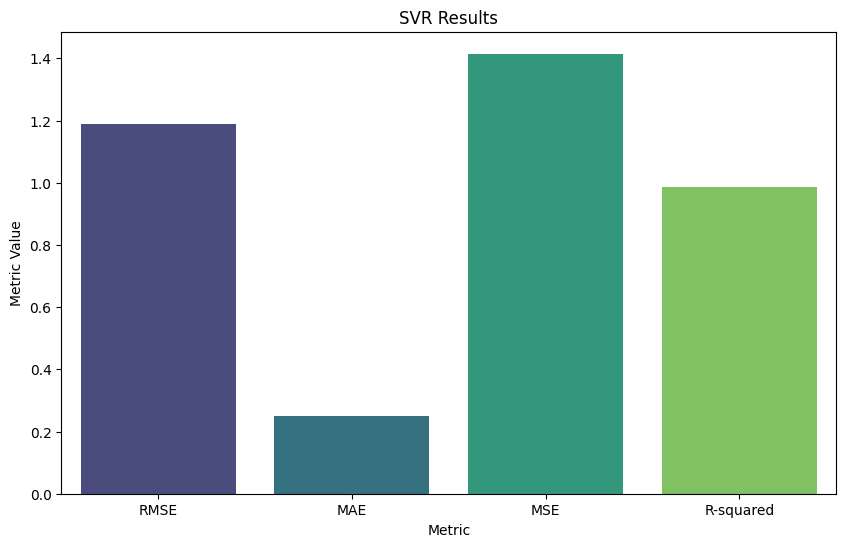

In [39]:
model = SVR()
# Feature selection using SelectFromModel
try:
  sfm = SelectFromModel(model)
  X_train_selected = sfm.fit_transform(X_train, y_train)
  X_test_selected = sfm.transform(X_test)
except ValueError as e:
  print(f"Ignoring the model due to error: {e}")

# Model fitting
model.fit(X_train_selected, y_train)

# Predictions
y_pred = model.predict(X_test_selected)

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"\nMetrics for SVR with SelectFromModel:")
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))
# Store results
result_SVR = {'RMSE': rmse, 'MAE': mae, 'MSE': mse, 'R-squared': r2}

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(result_SVR.keys()), y=list(result_SVR.values()), palette="viridis")
plt.title('SVR Results')
plt.xlabel('Metric')
plt.ylabel('Metric Value')
plt.show()

# Comparison

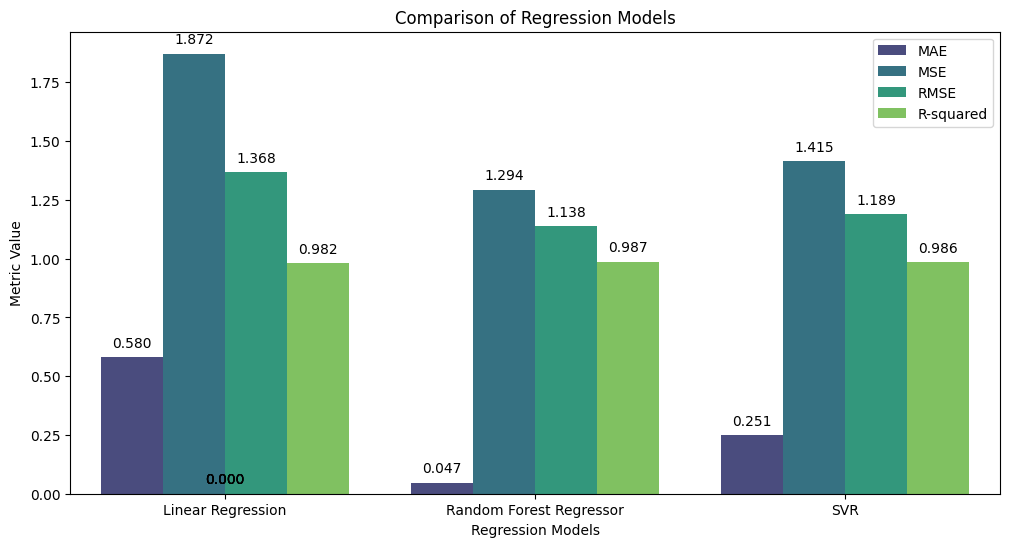

In [40]:
results_df_SelectFModel = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor', 'SVR'],
    'MAE': [result_LR['MAE'], result_RFR['MAE'], result_SVR['MAE']],
    'MSE': [result_LR['MSE'], result_RFR['MSE'], result_SVR['MSE']],
    'RMSE': [result_LR['RMSE'], result_RFR['RMSE'], result_SVR['RMSE']],
    'R-squared': [result_LR['R-squared'], result_RFR['R-squared'], result_SVR['R-squared']]
})

# Melt the DataFrame to make it suitable for Seaborn
results_melted = pd.melt(results_df_SelectFModel, id_vars='Model', var_name='Metric', value_name='Value')

# Plot the results with annotations
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Model', y='Value', hue='Metric', data=results_melted, palette="viridis")
plt.title('Comparison of Regression Models')
plt.ylabel('Metric Value')
plt.xlabel('Regression Models')

# Adjust legend position
plt.legend(bbox_to_anchor=(1, 1))

# Add annotations on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

# **Forward Sequential Feature Selector**

# Linear Regression

Metrics for Linear Regression with SelectKBest:
Selected Features: Index(['PRODUCT', 'Account Age', 'Monthly Usage(GBs)', 'Cumulative Usage(GBs)',
       'Max Usage(GBs)'],
      dtype='object')
MAE: 0.543
MSE: 1.741
RMSE: 1.32
R²: 0.983


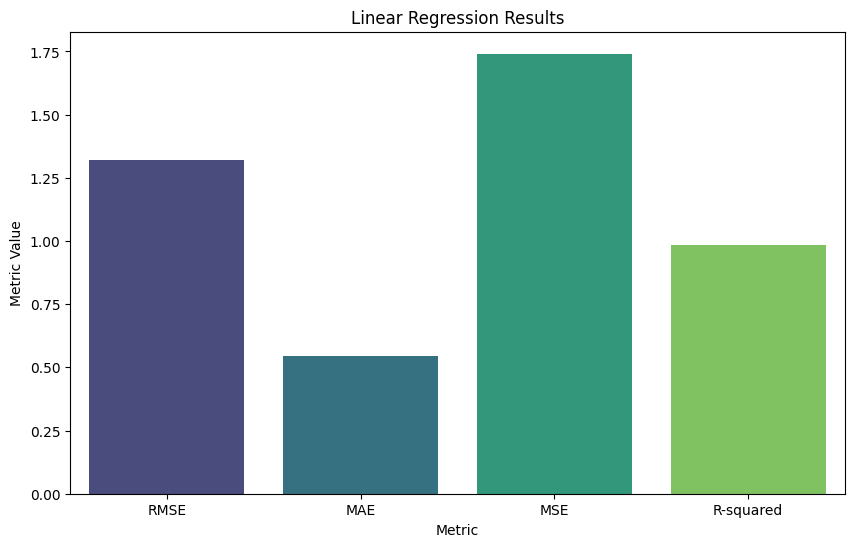

In [41]:
model= LinearRegression()

# Feature selection
sfs = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)
X_train_selected = sfs.transform(X_train)
X_test_selected = sfs.transform(X_test)

# Model fitting
model.fit(X_train_selected, y_train)

# Predictions
y_pred = model.predict(X_test_selected)

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("Metrics for Linear Regression with SelectKBest:")
print("Selected Features:", X.columns[sfs.get_support()])
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

result_LR = {'RMSE': rmse, 'MAE': mae, 'MSE': mse, 'R-squared': r2}

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(result_LR.keys()), y=list(result_LR.values()), hue=list(result_LR.keys()), palette="viridis", legend=False)
plt.title('Linear Regression Results')
plt.xlabel('Metric')
plt.ylabel('Metric Value')
plt.show()


# Random Forest Regressor

Metrics for Random Forest Regressor with SelectKBest:
Selected Features: Index(['PRODUCT', 'Account Age', 'Monthly Usage(GBs)', 'Cumulative Usage(GBs)',
       'Max Usage(GBs)'],
      dtype='object')
MAE: 0.047
MSE: 1.273
RMSE: 1.128
R²: 0.987


<ipython-input-42-bcb1bf279a55>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(result_RFR.keys()), y=list(result_RFR.values()), palette="viridis")


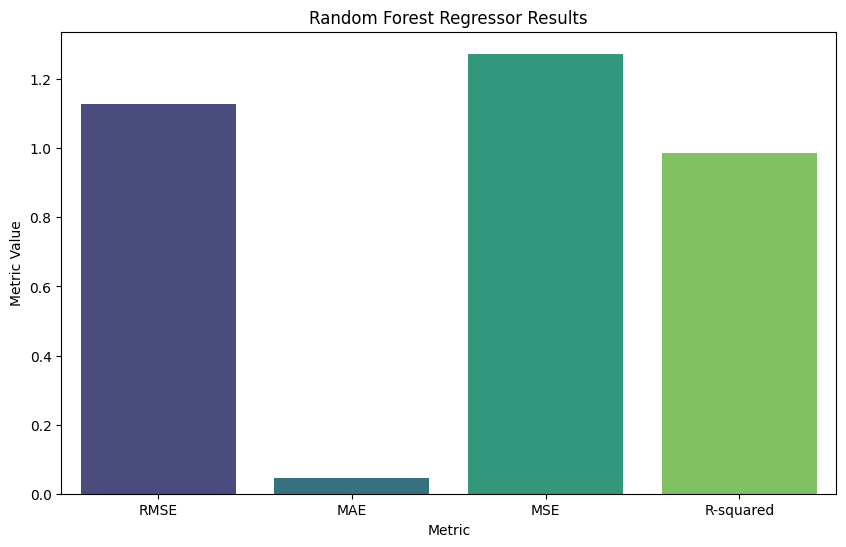

In [42]:
model= RandomForestRegressor()

# Feature selection
sfs = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)
X_train_selected = sfs.transform(X_train)
X_test_selected = sfs.transform(X_test)

# Model fitting
model.fit(X_train_selected, y_train)

# Predictions
y_pred = model.predict(X_test_selected)

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("Metrics for Random Forest Regressor with SelectKBest:")
print("Selected Features:", X.columns[sfs.get_support()])
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

result_RFR = {'RMSE': rmse, 'MAE': mae, 'MSE': mse, 'R-squared': r2}

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(result_RFR.keys()), y=list(result_RFR.values()), palette="viridis")
plt.title('Random Forest Regressor Results')
plt.xlabel('Metric')
plt.ylabel('Metric Value')
plt.show()

# SVR

Metrics for K Neighbors Regressor with SelectKBest:
Selected Features: Index(['CUSTOMER_TYPE', 'Account Age', 'Monthly Usage(GBs)',
       'Cumulative Usage(GBs)', 'Max Usage(GBs)'],
      dtype='object')
MAE: 0.373
MSE: 2.024
RMSE: 1.423
R²: 0.98


<ipython-input-43-56340c011a5a>:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(result_SVR.keys()), y=list(result_SVR.values()), palette="viridis")


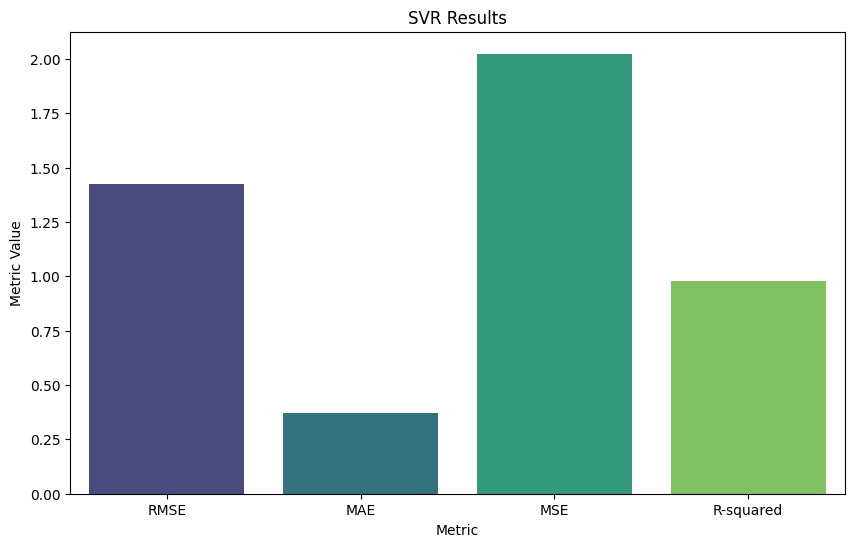

In [43]:
model= SVR()

# Feature selection using SelectKBest
sfs = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward')
sfs.fit(X_train, y_train)
X_train_selected = sfs.transform(X_train)
X_test_selected = sfs.transform(X_test)

# Model fitting
model.fit(X_train_selected, y_train)

# Predictions
y_pred = model.predict(X_test_selected)

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("Metrics for K Neighbors Regressor with SelectKBest:")
print("Selected Features:", X.columns[sfs.get_support()])
print("MAE:", round(mae, 3))
print("MSE:", round(mse, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

result_SVR = {'RMSE': rmse, 'MAE': mae, 'MSE': mse, 'R-squared': r2}

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x=list(result_SVR.keys()), y=list(result_SVR.values()), palette="viridis")
plt.title('SVR Results')
plt.xlabel('Metric')
plt.ylabel('Metric Value')
plt.show()

# Comparasion

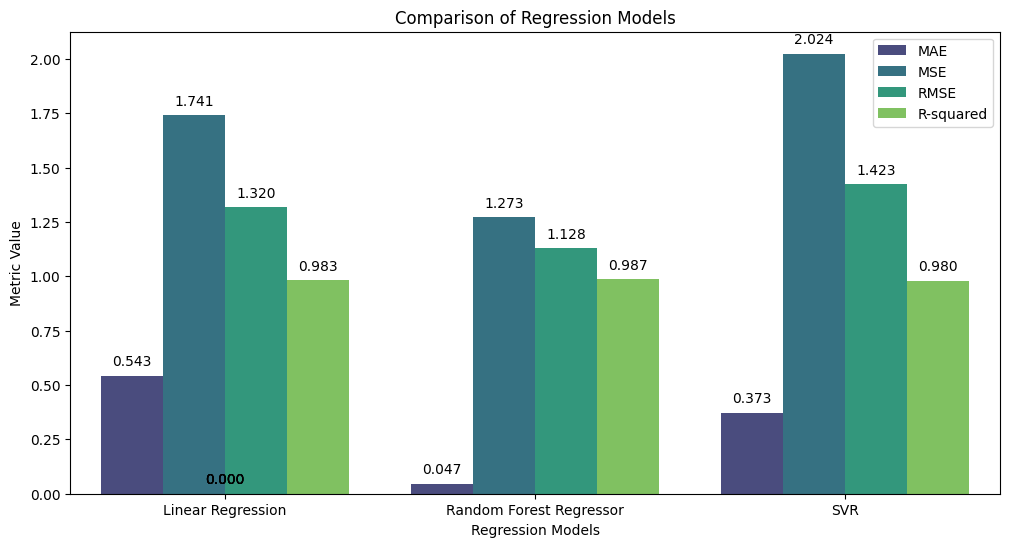

In [44]:
results_df_kBest = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor', 'SVR'],
    'MAE': [result_LR['MAE'], result_RFR['MAE'], result_SVR['MAE']],
    'MSE': [result_LR['MSE'], result_RFR['MSE'], result_SVR['MSE']],
    'RMSE': [result_LR['RMSE'], result_RFR['RMSE'], result_SVR['RMSE']],
    'R-squared': [result_LR['R-squared'], result_RFR['R-squared'], result_SVR['R-squared']]
})

# Melt the DataFrame to make it suitable for Seaborn
results_melted = pd.melt(results_df_kBest, id_vars='Model', var_name='Metric', value_name='Value')

# Plot the results with annotations
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Model', y='Value', hue='Metric', data=results_melted, palette="viridis")
plt.title('Comparison of Regression Models')
plt.ylabel('Metric Value')
plt.xlabel('Regression Models')

# Adjust legend position
plt.legend(bbox_to_anchor=(1, 1))

# Add annotations on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

# **Linear Programming**

# Linear Programming for Product 1

In [93]:
# Define the coefficients of the objective function
c = [-15]  # Coefficients for maximizing profit

# Define the coefficients of the constraints (left-hand side matrix) 2D list
A = [
    [200]
]

# Define the right-hand side of the constraints 1D list
b = [500000]  # Available amounts of GB

# Define the bounds for each variable (non-negative) Decision variables
x0_bounds = (0, None)  # Product 1


# Solve the linear programming problem (highs --> to minimze , simplex --> to maxximize)

result = linprog(c, A_ub=A, b_ub=b, bounds=[x0_bounds], method='highs')


# Display the results
print("Optimal number of product 1:", round(result.x[0]))
print("Maximum profit:", -round(result.fun))


Optimal number of product 1: 2500
Maximum profit: 37500


In [88]:
# Objective function coefficients for maximizing profit
c = [-15]

# Objective function (to maximize profit)
# The objective function is the sum of the product of coefficients and decision variables
objective_function = f"Maximize: {-c[0]} * x0 "

print("Objective function:")
print(objective_function)

Objective function:
Maximize: 15 * x0 


# Linear Programming for Product 2

In [94]:
# Define the coefficients of the objective function
c = [-20]  # Coefficients for maximizing profit

# Define the coefficients of the constraints (left-hand side matrix) 2D list
A = [
    [180]
]

# Define the right-hand side of the constraints 1D list
b = [500000]  # Available amounts of GB

# Define the bounds for each variable (non-negative) Decision variables
x0_bounds = (0, None)  # Product 2


# Solve the linear programming problem (highs --> to minimze , simplex --> to maxximize)

result = linprog(c, A_ub=A, b_ub=b, bounds=[x0_bounds], method='highs')


# Display the results
print("Optimal number of product 2:", round(result.x[0]))
print("Maximum profit:", -round(result.fun))


Optimal number of product 1: 2778
Maximum profit: 55556


In [95]:
# Objective function coefficients for maximizing profit
c = [-20]

# Objective function (to maximize profit)
# The objective function is the sum of the product of coefficients and decision variables
objective_function = f"Maximize: {-c[0]} * x0 "

print("Objective function:")
print(objective_function)

Objective function:
Maximize: 20 * x0 


# Linear Programming for Both Products

In [96]:
# Define the coefficients of the objective function
c = [-15, -20]  # Coefficients for maximizing profit

# Define the coefficients of the constraints (left-hand side matrix) 2D list
A = [
    [200, 180]
]

# Define the right-hand side of the constraints 1D list
b = [500000]  # Available amounts of GB

# Define the bounds for each variable (non-negative) Decision variables
x0_bounds = (0, None)  # Product 1
x1_bounds = (0, None)  # Product 2

# Solve the linear programming problem (highs --> to minimze , simplex --> to maxximize)

result = linprog(c, A_ub=A, b_ub=b, bounds=[x0_bounds, x1_bounds], method='highs')


# Display the results
print("Optimal number of product 1:", round(result.x[0]))
print("Optimal number of product 2:", round(result.x[1]))
print("Maximum profit:", -round(result.fun))


Optimal number of product 1: 0
Optimal number of product 2: 2778
Maximum profit: 55556


In [97]:
# Objective function coefficients for maximizing profit
c = [-15, -20]

# Objective function (to maximize profit)
# The objective function is the sum of the product of coefficients and decision variables
objective_function = f"Maximize: {-c[0]} * x0 + {-c[1]} * x1"

print("Objective function:")
print(objective_function)

Objective function:
Maximize: 15 * x0 + 20 * x1
